# Multi-Output Classification: Analyzing the Impact of Remote Work on Mental Health
Projek Remote Work & Mental Healt

Projek ini dirancang untuk pembelajaran pada matakuliah Machine Learning

## Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
import os

Dataset Yang digunakan: https://www.kaggle.com/code/mustafashoukat/remote-work-and-mental-health/input

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("waqi786/remote-work-and-mental-health")

print("Path to dataset files:", path)

e:\UAG\Semester 4\Machine Learning\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\syafi\.cache\kagglehub\datasets\waqi786\remote-work-and-mental-health\versions\1


In [3]:
# Mencari file CSV didalam folder hasil download
files = os.listdir(path)
print(f"files in dataset : {files}")

files in dataset : ['Impact_of_Remote_Work_on_Mental_Health.csv']


In [4]:
csv_files = [file for file in files if file.endswith('.csv')][0]

In [5]:
# baca dataset kepandas
df_remote_work = pd.read_csv(os.path.join(path, csv_files))

In [6]:
df_remote_work.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


## Exploratory Data Analysis (EDA)

Pahami Data:
- Jumlah data dan jumlah features
- Pahami setiap features mendeskripsikan data tentang apa (bisa melihat dari
dekspriksi data pada sumber data (jika tersedia) atau melihat dari isi data)
- Pahami apakah isi data telah sesuai dengan tipe data dan menggambarkan dari
deskripsi features data tersebut
- Tentukan feature target model dan pahami isi data dari feature tersebut apakah
kategorikal atau numerik yang bersifat kontinue (hal ini yang akan menentukan
apakah classification atau regression learning model)
- Pahami unik data nya (label/kelas) target model
- Pahami distribusi jumlah data berdasarkan label data target model
- Pahami apakah terdapat data yang kosong dari setiap features
- Pahami apakah terdapat data yang duplikat
- Pahami korelasi data dari setiap features

In [7]:
#cek dimensi data (banyaknya instans dan Feature)
df_remote_work.shape

(5000, 20)

In [8]:
#cek nama feature
df_remote_work.columns

Index(['Employee_ID', 'Age', 'Gender', 'Job_Role', 'Industry',
       'Years_of_Experience', 'Work_Location', 'Hours_Worked_Per_Week',
       'Number_of_Virtual_Meetings', 'Work_Life_Balance_Rating',
       'Stress_Level', 'Mental_Health_Condition',
       'Access_to_Mental_Health_Resources', 'Productivity_Change',
       'Social_Isolation_Rating', 'Satisfaction_with_Remote_Work',
       'Company_Support_for_Remote_Work', 'Physical_Activity', 'Sleep_Quality',
       'Region'],
      dtype='object')

In [9]:
print (df_remote_work.shape)
print (df_remote_work.columns)
print (df_remote_work.head)

(5000, 20)
Index(['Employee_ID', 'Age', 'Gender', 'Job_Role', 'Industry',
       'Years_of_Experience', 'Work_Location', 'Hours_Worked_Per_Week',
       'Number_of_Virtual_Meetings', 'Work_Life_Balance_Rating',
       'Stress_Level', 'Mental_Health_Condition',
       'Access_to_Mental_Health_Resources', 'Productivity_Change',
       'Social_Isolation_Rating', 'Satisfaction_with_Remote_Work',
       'Company_Support_for_Remote_Work', 'Physical_Activity', 'Sleep_Quality',
       'Region'],
      dtype='object')
<bound method NDFrame.head of      Employee_ID  Age      Gender           Job_Role    Industry  \
0        EMP0001   32  Non-binary                 HR  Healthcare   
1        EMP0002   40      Female     Data Scientist          IT   
2        EMP0003   59  Non-binary  Software Engineer   Education   
3        EMP0004   27        Male  Software Engineer     Finance   
4        EMP0005   49        Male              Sales  Consulting   
...          ...  ...         ...              

In [10]:
#cek isi data
df_remote_work.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [11]:
#cel tipe data
df_remote_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Employee_ID                        5000 non-null   object
 1   Age                                5000 non-null   int64 
 2   Gender                             5000 non-null   object
 3   Job_Role                           5000 non-null   object
 4   Industry                           5000 non-null   object
 5   Years_of_Experience                5000 non-null   int64 
 6   Work_Location                      5000 non-null   object
 7   Hours_Worked_Per_Week              5000 non-null   int64 
 8   Number_of_Virtual_Meetings         5000 non-null   int64 
 9   Work_Life_Balance_Rating           5000 non-null   int64 
 10  Stress_Level                       5000 non-null   object
 11  Mental_Health_Condition            3804 non-null   object
 12  Access

In [12]:
# cek kolom dengan tipe data object
object_cols= df_remote_work.select_dtypes(include=['object']).columns

# lop untuk menampilkan nilai unik setiap kolom object
for col in object_cols:
  print(f"\nKolom: {col}")
  print("jumlah nilai unik: ", df_remote_work[col].nunique())
  print("Daftar Nilai Unik", df_remote_work[col].unique())



Kolom: Employee_ID
jumlah nilai unik:  5000
Daftar Nilai Unik ['EMP0001' 'EMP0002' 'EMP0003' ... 'EMP4998' 'EMP4999' 'EMP5000']

Kolom: Gender
jumlah nilai unik:  4
Daftar Nilai Unik ['Non-binary' 'Female' 'Male' 'Prefer not to say']

Kolom: Job_Role
jumlah nilai unik:  7
Daftar Nilai Unik ['HR' 'Data Scientist' 'Software Engineer' 'Sales' 'Marketing' 'Designer'
 'Project Manager']

Kolom: Industry
jumlah nilai unik:  7
Daftar Nilai Unik ['Healthcare' 'IT' 'Education' 'Finance' 'Consulting' 'Manufacturing'
 'Retail']

Kolom: Work_Location
jumlah nilai unik:  3
Daftar Nilai Unik ['Hybrid' 'Remote' 'Onsite']

Kolom: Stress_Level
jumlah nilai unik:  3
Daftar Nilai Unik ['Medium' 'High' 'Low']

Kolom: Mental_Health_Condition
jumlah nilai unik:  3
Daftar Nilai Unik ['Depression' 'Anxiety' nan 'Burnout']

Kolom: Access_to_Mental_Health_Resources
jumlah nilai unik:  2
Daftar Nilai Unik ['No' 'Yes']

Kolom: Productivity_Change
jumlah nilai unik:  3
Daftar Nilai Unik ['Decrease' 'Increase' 'No

coba cek yang Non-binary ada brp?


*   cek mana aja label yang akan digunakan
*   dan gunakan multilabel
*   dan tentukan y yang akan digunakannya

atribut di hapus
- Employee_ID
- Gender







In [13]:
non_binary_data = df_remote_work[df_remote_work['Gender'] == 'Non-binary']
print(f"Data untuk gender 'Non-binary':\n{non_binary_data.head()}\n")
print(f"Jumlah data dengan gender 'Non-binary': {len(non_binary_data)}")

Data untuk gender 'Non-binary':
   Employee_ID  Age      Gender           Job_Role       Industry  \
0      EMP0001   32  Non-binary                 HR     Healthcare   
2      EMP0003   59  Non-binary  Software Engineer      Education   
5      EMP0006   59  Non-binary              Sales             IT   
7      EMP0008   42  Non-binary     Data Scientist  Manufacturing   
10     EMP0011   33  Non-binary  Software Engineer        Finance   

    Years_of_Experience Work_Location  Hours_Worked_Per_Week  \
0                    13        Hybrid                     47   
2                    22        Hybrid                     46   
5                    31        Hybrid                     39   
7                     6        Onsite                     54   
10                   17        Remote                     48   

    Number_of_Virtual_Meetings  Work_Life_Balance_Rating Stress_Level  \
0                            7                         2       Medium   
2                     

In [14]:
#cek unik data (label/kelas) untuk feature target
print ("jumlah nilai unik :", df_remote_work['Mental_Health_Condition'].nunique())
print ("daftar nilai unik :", df_remote_work['Mental_Health_Condition'].unique())

jumlah nilai unik : 3
daftar nilai unik : ['Depression' 'Anxiety' nan 'Burnout']


In [15]:
# jumlah data berdasarkan label/kelas target
df_remote_work.groupby('Mental_Health_Condition').size()

Mental_Health_Condition
Anxiety       1278
Burnout       1280
Depression    1246
dtype: int64

In [16]:
#cek kolom data yang kosong (missing value )
df_remote_work.isnull().sum()

Employee_ID                             0
Age                                     0
Gender                                  0
Job_Role                                0
Industry                                0
Years_of_Experience                     0
Work_Location                           0
Hours_Worked_Per_Week                   0
Number_of_Virtual_Meetings              0
Work_Life_Balance_Rating                0
Stress_Level                            0
Mental_Health_Condition              1196
Access_to_Mental_Health_Resources       0
Productivity_Change                     0
Social_Isolation_Rating                 0
Satisfaction_with_Remote_Work           0
Company_Support_for_Remote_Work         0
Physical_Activity                    1629
Sleep_Quality                           0
Region                                  0
dtype: int64

untuk data yang missing di perlukan di drop karena tidak bisa mengisi data yang kosong bukan ahlinya

In [17]:
#cek unik data (label/kelas) untuk feature target
print ("jumlah nilai unik :", df_remote_work['Physical_Activity'].nunique())
print ("daftar nilai unik :", df_remote_work['Physical_Activity'].unique())

jumlah nilai unik : 2
daftar nilai unik : ['Weekly' nan 'Daily']


In [18]:
#cek jumlah missing value secara keseluruuhan
df_remote_work.isnull().sum().sum()

np.int64(2825)

In [19]:
# cek data duplicated
print("jumlah data Duplikat", df_remote_work.duplicated().sum())

jumlah data Duplikat 0


In [20]:
# Sorting the unique values of the "Age" column
sorted_ages = sorted(df_remote_work["Age"].unique())
print(sorted_ages)

[np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60)]


In [21]:
# Count the occurrences of each job role
job_role_counts = df_remote_work['Job_Role'].value_counts()

# Display the job role counts
print("Number of people in each job role:")
print(job_role_counts)

Number of people in each job role:
Job_Role
Project Manager      738
Sales                733
Designer             723
HR                   716
Software Engineer    711
Data Scientist       696
Marketing            683
Name: count, dtype: int64


In [22]:
# filter atribut numerik
num_colomns= df_remote_work.select_dtypes(include= ['int64', 'float64'])

#media
median_values = num_colomns.median()

print("Nilai Median untuk Setiap Kolom bertipe integer dan float:")
print(median_values)

Nilai Median untuk Setiap Kolom bertipe integer dan float:
Age                                41.0
Years_of_Experience                18.0
Hours_Worked_Per_Week              40.0
Number_of_Virtual_Meetings          8.0
Work_Life_Balance_Rating            3.0
Social_Isolation_Rating             3.0
Company_Support_for_Remote_Work     3.0
dtype: float64


In [23]:
#correlation
coor_matrix=num_colomns.corr()

print("Matriks berkorelasi antara kolom integer dan float: \n")
print(coor_matrix)

Matriks berkorelasi antara kolom integer dan float: 

                                      Age  Years_of_Experience  \
Age                              1.000000            -0.004480   
Years_of_Experience             -0.004480             1.000000   
Hours_Worked_Per_Week           -0.001352            -0.018537   
Number_of_Virtual_Meetings       0.003617             0.019043   
Work_Life_Balance_Rating         0.017697             0.001698   
Social_Isolation_Rating         -0.024992             0.001691   
Company_Support_for_Remote_Work  0.023673             0.007240   

                                 Hours_Worked_Per_Week  \
Age                                          -0.001352   
Years_of_Experience                          -0.018537   
Hours_Worked_Per_Week                         1.000000   
Number_of_Virtual_Meetings                   -0.004609   
Work_Life_Balance_Rating                      0.000820   
Social_Isolation_Rating                      -0.005006   
Company_Sup

In [24]:
# tedensi sentral
df_remote_work.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,40.9950,11.296021,22.0,31.0,41.0,51.0,60.0
Years_of_Experience,5000.0,17.8102,10.020412,1.0,9.0,18.0,26.0,35.0
Hours_Worked_Per_Week,5000.0,39.6146,11.860194,20.0,29.0,40.0,50.0,60.0
Number_of_Virtual_Meetings,5000.0,7.5590,4.636121,0.0,4.0,8.0,12.0,15.0
Work_Life_Balance_Rating,5000.0,2.9842,1.410513,1.0,2.0,3.0,4.0,5.0
Social_Isolation_Rating,5000.0,2.9938,1.394615,1.0,2.0,3.0,4.0,5.0
Company_Support_for_Remote_Work,5000.0,3.0078,1.399046,1.0,2.0,3.0,4.0,5.0


**Insight Exploratory Data Analysis (EDA):**

- Dimensi & Tipe Data: Dataset berskala memadai dengan 5.000 baris dan 20 kolom (terdiri dari 7 fitur numerik dan 13 fitur kategorikal).

- Identifikasi Target (Multi-Output): Terdapat tiga kolom kategorikal yang difokuskan sebagai label target prediksi, yaitu Sleep_Quality, Stress_Level, dan Mental_Health_Condition.

- Temuan Missing Values: Terdeteksi adanya nilai kosong (NaN) pada fitur Physical_Activity dan target Mental_Health_Condition. Diperlukan strategi penanganan (imputasi data atau penghapusan baris) agar tidak mendistorsi hasil model.

- Kebutuhan Preprocessing: Seluruh kolom dengan tipe data object (seperti Gender, Job_Role, dan Work_Location) wajib dikonversi menjadi format numerik melalui proses Encoding.

## Data Visualization
Seaborn: Seaborn merupakan salah satu pustaka visual Python yang berlandaskan
pada matplotlib. Seaborn menyediakan antar-muka tingkat tinggi untuk menangani
permasalahan terkait visualisasi data secara statistik agar tampak lebih menarik.
Pahami Data:
- Apakah terdapat outlier dari setiap features
- Pahami hubungan diantara features

### Bar Chart

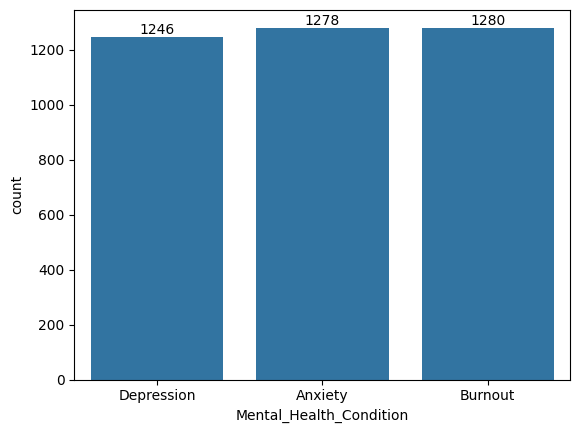

In [25]:
#bar Chart
count = sns.countplot(x = 'Mental_Health_Condition', data = df_remote_work)

for j in count.patches:
    count.annotate(format(j.get_height(), '.0f'),
     (j.get_x() + j.get_width() / 2., j.get_height()),
                   ha ='center',
                   va ='center',
                   xytext =(0, 5),
                   textcoords ='offset points')

plt.show()

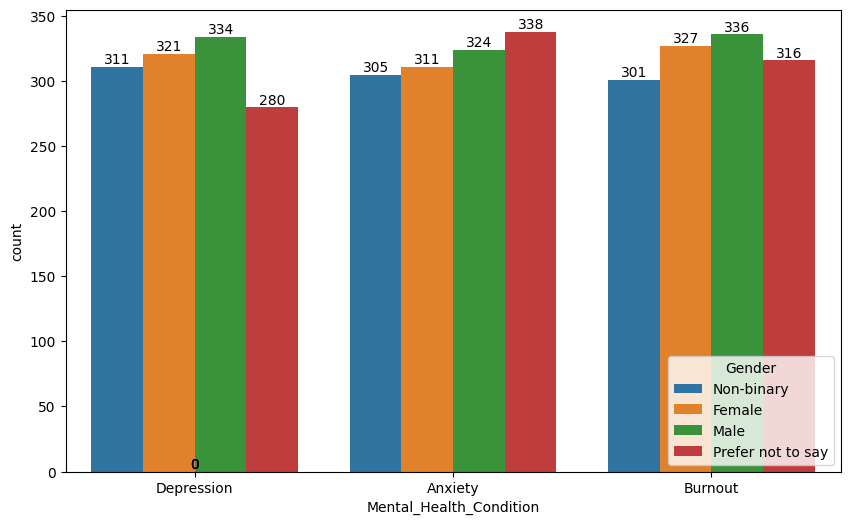

In [26]:
#bar Chart
f, ax = plt.subplots(figsize=(10, 6)) # Create figure and axes
count_plot = sns.countplot(x='Mental_Health_Condition', hue='Gender', data=df_remote_work, ax=ax)

for j in count_plot.patches:
    count_plot.annotate(format(j.get_height(), '.0f'),
     (j.get_x() + j.get_width() / 2., j.get_height()),
                   ha ='center',
                   va ='center',
                   xytext =(0, 5),
                   textcoords ='offset points')

plt.show()

### Boxplot

<Axes: xlabel='Mental_Health_Condition', ylabel='Years_of_Experience'>

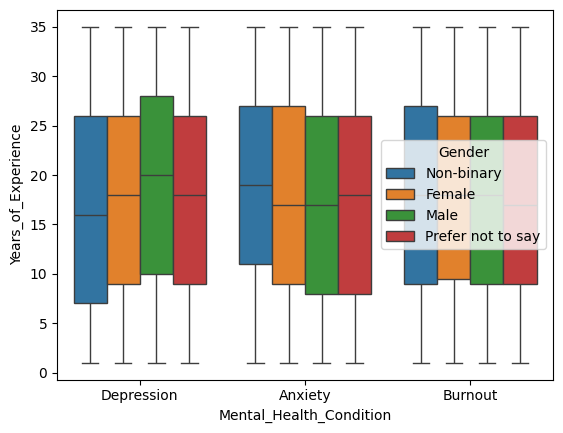

In [27]:
# boxplot
sns.boxplot(x='Mental_Health_Condition', y='Years_of_Experience', hue='Gender', data=df_remote_work)

{'whiskers': [<matplotlib.lines.Line2D at 0x278024c5d80>,
 'caps': [<matplotlib.lines.Line2D at 0x27800267c40>,
 'boxes': [<matplotlib.lines.Line2D at 0x278024c61d0>],
 'medians': [<matplotlib.lines.Line2D at 0x278002fa260>],
 'fliers': [<matplotlib.lines.Line2D at 0x278002f9570>],
 'means': []}

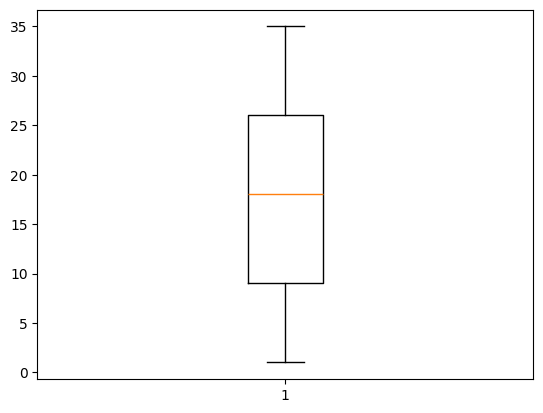

In [28]:
plt.boxplot(df_remote_work["Years_of_Experience"])

<Axes: >

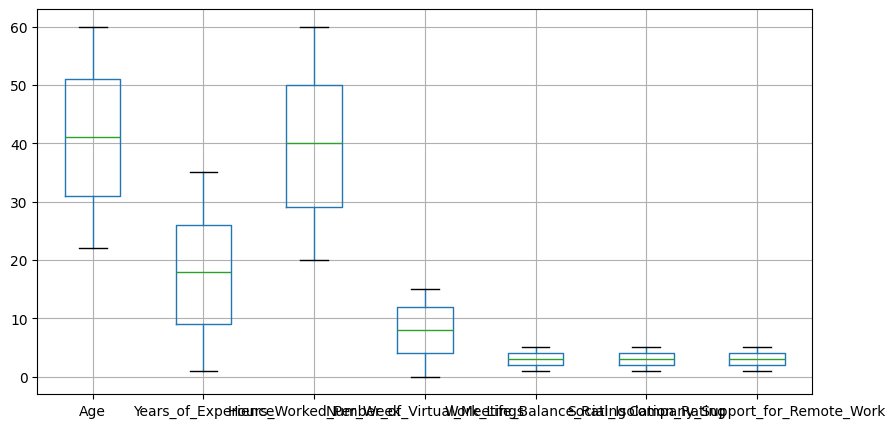

In [29]:
df_remote_work.boxplot(figsize=(10,5))

### Heatmap(Correlation)

<Axes: >

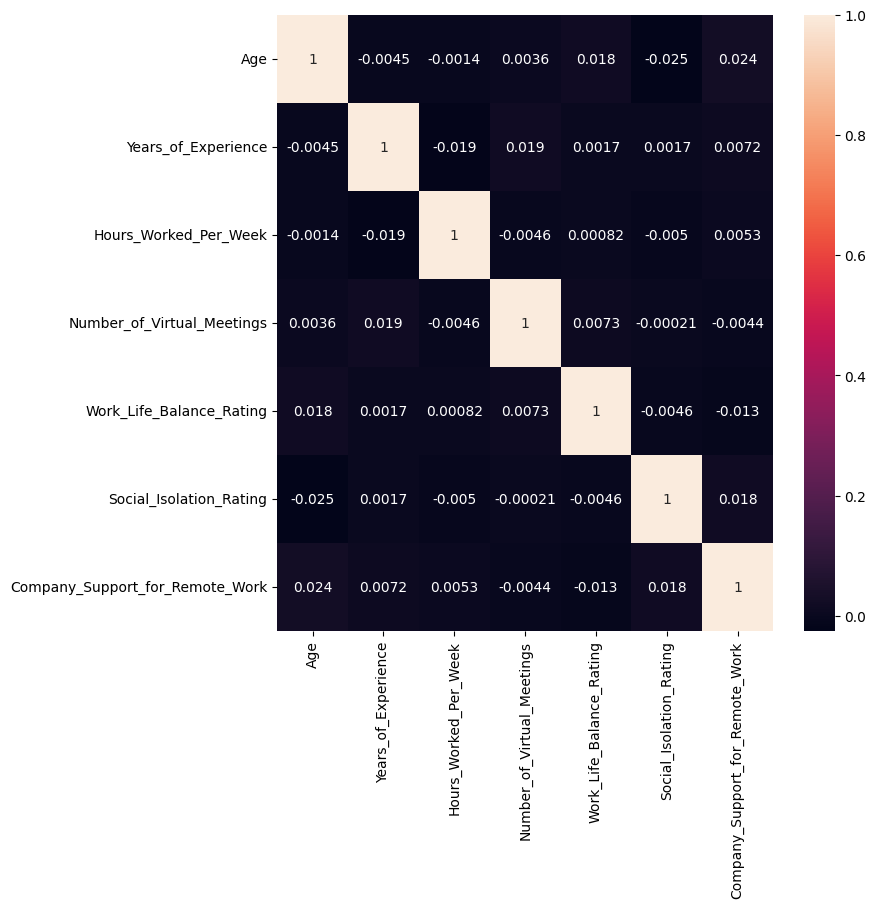

In [30]:
# heatmap correlation
plt.subplots(figsize=(8,8))
sns.heatmap(num_colomns.corr(), annot=True)

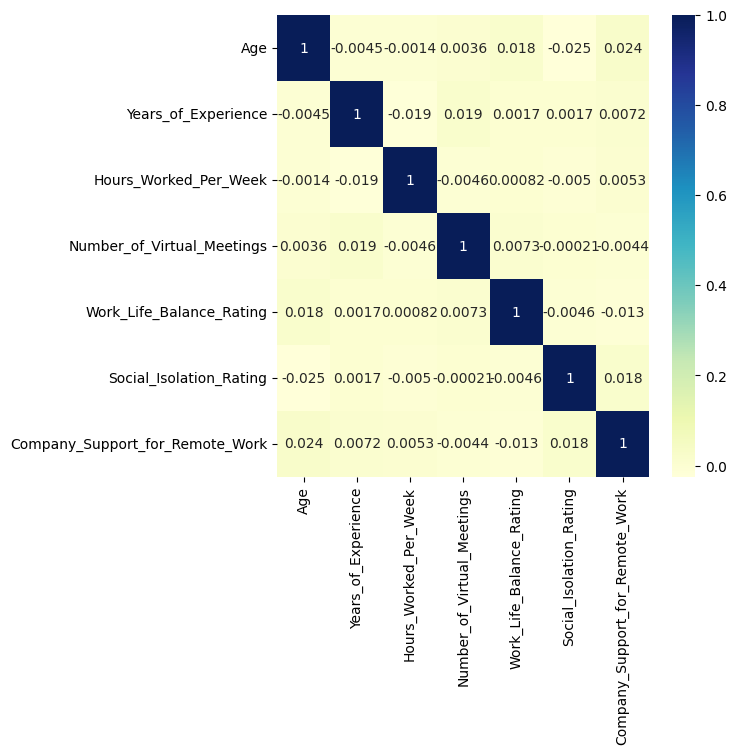

In [31]:
# Ploting Correlation heatmap
plt.subplots(figsize=(6,6))
dataplot = sns.heatmap(num_colomns.corr(), cmap="YlGnBu", annot=True)

#display heatmap
plt.show()

nilai korelasi tertinggi hanya terjadi antara variabel usia (Age) dengan dukungan perusahaan (Company_Support_for_Remote_Work) yaitu sebesar 0,0236, sedangkan metrik korelasi antar variabel independen lainnya mendekati angka nol. Hal ini ditunjukkan secara jelas pada visualisasi peta panas (Heatmap) matriks korelasi.

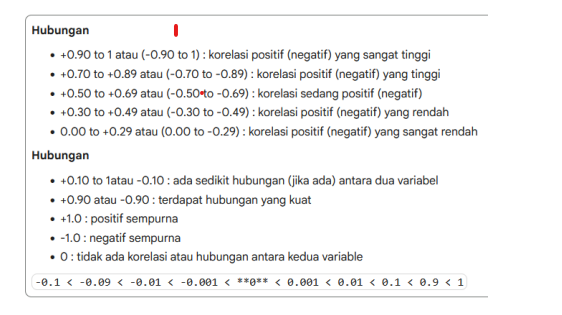

### Pie Chart

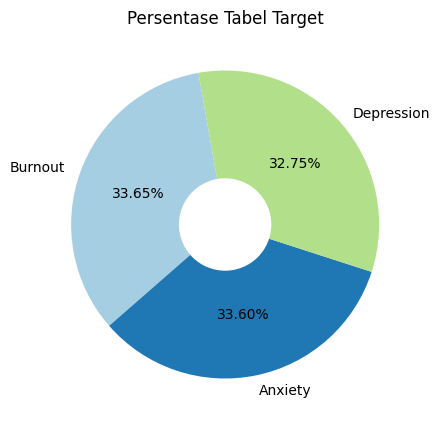

In [33]:
plt.figure(figsize=(5, 5))

value_counts = df_remote_work.Mental_Health_Condition.value_counts()
plt.pie(value_counts,
        labels=value_counts.index.fillna('Unknown'), # Use actual condition names as labels, handle NaN if any
        colors = plt.cm.Paired.colors,
        autopct='%2.2f%%',
        startangle = 100,
        wedgeprops=dict(width=0.8))

plt.gca().add_artist(plt.Circle((0, 0), 0.30, fc='white'))
plt.title('Persentase Tabel Target')
plt.show()

insigt: 

- Usia dan Pekerjaan Jarak Jauh: Kelompok usia yang lebih muda (25-34) dan lebih tua (45-54) lebih banyak terlibat dalam pekerjaan jarak jauh.

- Tingkat Stres: Ada hubungan positif antara pekerjaan jarak jauh dan stres, dimana pekerja jarak jauh melaporkan tingkat stres yang lebih tinggi.

- Tren Industri: Keuangan, TI, dan Layanan Kesehatan adalah sektor-sektor teratas yang mengadopsi pekerjaan jarak jauh, yang menunjukkan adanya pergeseran ke arah pengaturan kerja yang fleksibel.

- Jam Kerja: Jam kerja cenderung meningkat seiring bertambahnya usia, terutama setelah usia 35 tahun, yang menunjukkan tanggung jawab yang lebih besar di antara karyawan yang lebih tua.

- Peran dan Pengalaman Kerja: Karyawan yang lebih berpengalaman cenderung bekerja jarak jauh, hal ini menunjukkan bahwa pengalaman industri mempengaruhi peluang kerja jarak jauh.

- Temuan ini menyoroti pentingnya mempertimbangkan kesehatan mental dan kesejahteraan karyawan ketika memahami pengaturan kerja jarak jauh.	

## Data Preprocessing

tahapan untuk menghilangkan beberapa
permasalahan pada data yang bisa mengganggu saat pemrosesan data.

### Data Cleaning

In [34]:
df_remote_work.shape

(5000, 20)

In [35]:
df_remote_work.head()

,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [36]:
df_remote_work = df_remote_work.drop(columns=['Physical_Activity'])

In [ ]:
# disini saya memutuskan untuk menghpus nilai kosong yang berada pada atribut 'Mental_Health_Condition'
# karena kita tidak bisa mengisi data kosong bukan ahlinya...
df_remote_work.dropna(subset=['Mental_Health_Condition'], inplace=True)
print (df_remote_work.isnull().sum().sum())
print (df_remote_work.shape)

0
(3804, 19)


In [38]:
df_remote_work.isnull().sum()

Employee_ID                          0
Age                                  0
Gender                               0
Job_Role                             0
Industry                             0
Years_of_Experience                  0
Work_Location                        0
Hours_Worked_Per_Week                0
Number_of_Virtual_Meetings           0
Work_Life_Balance_Rating             0
Stress_Level                         0
Mental_Health_Condition              0
Access_to_Mental_Health_Resources    0
Productivity_Change                  0
Social_Isolation_Rating              0
Satisfaction_with_Remote_Work        0
Company_Support_for_Remote_Work      0
Sleep_Quality                        0
Region                               0
dtype: int64

In [39]:
# menghapus beberapa atribut yang tidak digunakan
df_remote_work.drop(['Employee_ID', 'Gender','Industry','Work_Location','Region'], axis=1, inplace=True)
df_remote_work.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3804 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                3804 non-null   int64 
 1   Job_Role                           3804 non-null   object
 2   Years_of_Experience                3804 non-null   int64 
 3   Hours_Worked_Per_Week              3804 non-null   int64 
 4   Number_of_Virtual_Meetings         3804 non-null   int64 
 5   Work_Life_Balance_Rating           3804 non-null   int64 
 6   Stress_Level                       3804 non-null   object
 7   Mental_Health_Condition            3804 non-null   object
 8   Access_to_Mental_Health_Resources  3804 non-null   object
 9   Productivity_Change                3804 non-null   object
 10  Social_Isolation_Rating            3804 non-null   int64 
 11  Satisfaction_with_Remote_Work      3804 non-null   object
 12  Company_Sup

In [40]:
# merubah nama atribut
#df_remote_work.colomns =['id', 'umur','gender','jenis_pekerjaan', 'industri', 'pengalaman_pertahun', 'lokasi_kerja', 'jam_pekerjaan_permiggu', 'lama_metting', 'reting_pekerjaan', 'level_strees', 'kondisi_mental', 'akses_kesehatanmental','produktifitas_perubahan',	'rating_isolasi_sosial','Satisfaction_with_Remote_Work','pekerjaan_perusahaan',	'aktifitas_fisik',	'kualitas_tidur',	'wilayah' ]


In [41]:
df_remote_work.head()

,Age,Job_Role,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Sleep_Quality
0,32,HR,13,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Good
1,40,Data Scientist,3,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Good
2,59,Software Engineer,22,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,Poor
3,27,Software Engineer,20,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,Poor
6,31,Sales,24,51,7,3,Low,Anxiety,Yes,Decrease,5,Neutral,3,Poor


In [42]:
df_remote_work.groupby('Sleep_Quality').size()

Sleep_Quality
Average    1260
Good       1265
Poor       1279
dtype: int64

In [43]:
# salah satu teknik cleaning data (memperbaiki inkonsistensi data)
#df_remote_work['atribut'] = np.where(df_remote_work['atribut']=='No internet service', 'No', df_remote_work['atribut'])

#salah satu teknik cleaning data (mengisi nilai yang kosong )
#df_remote_work['Physical_Activity'].fillna(value=df_remote_work['Weekly'] * df_remote_work['Daily'], inplace=True)

#replace missing values with the median
#df_remote_work.fillna(df_remote_work.median(), inplace=True)

#teknik Cleaning data (mengisi dengan konstanta global),
# masing-masing missing value akan diganti dengan '...' (cell kosong)
#df_remote_work['atribut'] = np.where(df_remote_work['atribut'] == 'NaN', '', df_remote_work['atribut'])

In [44]:
# masing-masing nilai missing value akan diganti dengan 0
# df_remote_work['atribut'].fillna (0, inplace=true)

#dapat menghapus data kosong
# df_remotw_work.dropna(inplace = True)

#mengetahui jumlah missing value keseluruhan
#df_remote_work.isnull().sum().sum()

#merubah type data object menjadi float
#df_remote_work['atribut'] = pd.to_numeric(df_remote_work['atribut'], errors='coerce')

In [45]:
col = df_remote_work.select_dtypes(include = ['object']).columns
col

Index(['Job_Role', 'Stress_Level', 'Mental_Health_Condition',
       'Access_to_Mental_Health_Resources', 'Productivity_Change',
       'Satisfaction_with_Remote_Work', 'Sleep_Quality'],
      dtype='object')

### Feature Engineering 

In [46]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [49]:
#target
target_cols = ['Sleep_Quality', 'Stress_Level', 'Mental_Health_Condition']
X = df_remote_work.drop(columns=target_cols)
y = df_remote_work[target_cols]

In [50]:
# Pisahkan kolom berdasarkan tipe
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [51]:
# Encoding untuk kategorikal
X_encoded = pd.get_dummies(X, columns=cat_cols)

- Pandas mengambil kolom-kolom yang ada di cat_cols (kolom object), lalu mengubahnya menjadi beberapa kolom baru yang berisi angka 0 dan 1 (dummy variables).
- Pandas tetap mempertahankan kolom-kolom lain yang tidak masuk ke dalam cat_cols (yaitu num_cols yang bertipe int64 atau float64).
- Hasil akhirnya digabungkan kembali.    

In [52]:
encoders = {}
y_encoded = pd.DataFrame(index=y.index)

for col in target_cols:
    le = LabelEncoder()
    y_encoded[col] = le.fit_transform(y[col])
    encoders[col] = le 

### Pembagian Data 

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import MultiLabelBinarizer

In [54]:
x_train, x_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.25, random_state=42
)

In [55]:
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2853, 22)
y_train shape: (2853, 3)
X_test shape: (951, 22)
y_test shape: (951, 3)


### Feature Transformation (Feature Scalling)

In [56]:
sc= StandardScaler()
X_train_sc= sc.fit_transform(x_train)
X_test_sc= sc.transform(x_test)

In [57]:
y_train.head()

,Sleep_Quality,Stress_Level,Mental_Health_Condition
1150,1,0,0
3039,0,2,1
3311,2,2,2
2589,2,2,0
2116,2,2,1


In [58]:
x_train.head()

,Age,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Social_Isolation_Rating,Company_Support_for_Remote_Work,Job_Role_Data Scientist,Job_Role_Designer,Job_Role_HR,...,Job_Role_Sales,Job_Role_Software Engineer,Access_to_Mental_Health_Resources_No,Access_to_Mental_Health_Resources_Yes,Productivity_Change_Decrease,Productivity_Change_Increase,Productivity_Change_No Change,Satisfaction_with_Remote_Work_Neutral,Satisfaction_with_Remote_Work_Satisfied,Satisfaction_with_Remote_Work_Unsatisfied
1150,50,10,58,12,3,1,5,False,False,False,...,False,False,False,True,False,True,False,False,False,True
3039,33,32,47,12,2,4,1,False,False,False,...,False,False,True,False,True,False,False,True,False,False
3311,34,4,23,9,2,5,1,False,False,True,...,False,False,True,False,False,False,True,False,True,False
2589,60,13,21,2,3,1,3,False,True,False,...,False,False,True,False,False,False,True,False,True,False
2116,44,12,43,11,5,5,2,True,False,False,...,False,False,False,True,False,True,False,False,True,False


## Modeling
**Pendekatan Multi-Output Classification**

Untuk membangun arsitektur sistem yang lebih efektif dan rasional saat *deployment*, kita menggunakan pendekatan Multi-Output Classification. 

* **Satu Input Terpusat:** Model menerima satu matriks fitur utuh (gabungan metrik demografi, metrik kesejahteraan, dan pekerjaan).
* **Prediksi Simultan:** Dalam satu kali komputasi inference, model langsung mengeluarkan prediksi untuk 3 target sekaligus (`Sleep_Quality`, `Stress_Level`, dan `Mental_Health_Condition`).
* **Deployment Ringkas:** Arsitektur ini hanya menghasilkan 1 artefak objek model tunggal (`model_multi_output.pkl`), membuat kode aplikasi (seperti Streamlit) menjadi jauh lebih bersih dan ringan.

In [59]:
# Import metrik dan siapkan dictionary penyimpanan skor
from sklearn.metrics import accuracy_score


### Logistic Regression
Logistic Regression digunakan sebagai model *baseline*. Model ini menggunakan parameter `class_weight='balanced'` untuk menangani ketidakseimbangan kelas secara natural.

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

# 1. Inisialisasi model dasar Logistic Regression
# Catatan: max_iter diset 1000 agar model punya waktu cukup untuk konvergen (mencegah warning)
base_lr = LogisticRegression(max_iter=1000, random_state=42)

# 2. Bungkus model dasar agar bisa memprediksi 3 target sekaligus
model_multi_lr = MultiOutputClassifier(base_lr)

# 3. Proses Training model menggunakan data latih
print("Memulai proses training...")
model_multi_lr.fit(x_train, y_train)
print("Training selesai!")

# 4. Lakukan prediksi menggunakan data uji (x_test)
y_pred_lr = model_multi_lr.predict(x_test)

# Memastikan bentuk output prediksi sama dengan y_test
print("\nShape y_test asli:", y_test.shape)
print("Shape hasil prediksi:", y_pred_lr.shape)

Memulai proses training...
Training selesai!

Shape y_test asli: (951, 3)
Shape hasil prediksi: (951, 3)


max_iter=1000: Logistic Regression menggunakan iterasi matematika untuk menemukan pola. Jika datanya cukup kompleks (22 fitur), pengaturan bawaan (biasanya 100) sering kali kurang dan memunculkan warning "ConvergenceWarning". Menaikkan angkanya akan mengamankan proses training.

Hasil y_pred: Ketika kamu menjalankan .predict(x_test), hasilnya akan langsung berupa matriks berukuran (951, 3). Ini sudah memenuhi syarat dari dosenmu: 1 input, langsung 3 output!

### Random Forest

Membangun sekumpulan pohon keputusan (ensemble) secara paralel. Algoritma ini sangat kuat dalam menangani hubungan non-linear yang kompleks antar fitur dan ketiga target.

In [62]:
from sklearn.ensemble import RandomForestClassifier

# 1. Inisialisasi model Random Forest
# n_estimators=100 adalah jumlah 'pohon' (trees) yang akan dibuat. Semakin banyak biasanya semakin stabil, tapi komputasi lebih lama.
# random_state=42 agar hasilnya konsisten jika di-run berulang kali.
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Proses Training model menggunakan data latih
print("Memulai proses training Random Forest...")
model_rf.fit(x_train, y_train)
print("Training selesai!")

# 3. Lakukan prediksi menggunakan data uji (x_test)
y_pred_rf = model_rf.predict(x_test)

# Memastikan bentuk output prediksi
print("\nShape y_test asli:", y_test.shape)
print("Shape hasil prediksi RF:", y_pred_rf.shape)

Memulai proses training Random Forest...
Training selesai!

Shape y_test asli: (951, 3)
Shape hasil prediksi RF: (951, 3)


Parameter n_jobs=-1: Saya menambahkan parameter ini agar saat proses training, komputer menggunakan seluruh core CPU yang tersedia, sehingga proses latihannya bisa jauh lebih cepat.

### Decision Tree

Membentuk alur keputusan tunggal yang transparan dan mudah diinterpretasikan, meskipun memerlukan batasan parameter (hyperparameter tuning) agar tidak terjadi overfitting

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 1. Inisialisasi model Decision Tree
# random_state=42 agar hasilnya konsisten.
# Kamu juga bSisa menambahkan parameter seperti max_depth=5 untuk mencegah overfitting (opsional).
model_dt = DecisionTreeClassifier(random_state=42)

# 2. Proses Training model menggunakan data latih
print("Memulai proses training Decision Tree...")
model_dt.fit(x_train, y_train)
print("Training selesai!")

# 3. Lakukan prediksi menggunakan data uji (x_test)
y_pred_dt = model_dt.predict(x_test)

# Memastikan bentuk output prediksi
print("\nShape y_test asli:", y_test.shape)
print("Shape hasil prediksi DT:", y_pred_dt.shape)

Memulai proses training Decision Tree...
Training selesai!

Shape y_test asli: (951, 3)
Shape hasil prediksi DT: (951, 3)


### K-Nearest Neighbors (KNN)

Menentukan kelas berdasarkan jarak kedekatan antar titik data, yang mana sangat bergantung pada proses standardisasi skala data (feature scaling).

In [64]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Inisialisasi model KNN
# n_neighbors=5 adalah nilai bawaan (default). Kamu bisa mengubahnya nanti untuk mencari akurasi terbaik (Hyperparameter Tuning).
model_knn = KNeighborsClassifier(n_neighbors=5)

# 2. Proses Training model menggunakan data latih
print("Memulai proses training KNN...")
model_knn.fit(x_train, y_train)
print("Training selesai!")

# 3. Lakukan prediksi menggunakan data uji (x_test)
y_pred_knn = model_knn.predict(x_test)

# Memastikan bentuk output prediksi
print("\nShape y_test asli:", y_test.shape)
print("Shape hasil prediksi KNN:", y_pred_knn.shape)

Memulai proses training KNN...
Training selesai!

Shape y_test asli: (951, 3)
Shape hasil prediksi KNN: (951, 3)


### Evaluasi Akhir & Pemilihan Model
Membandingkan rata-rata akurasi dari ketiga arsitektur Classifier Chain untuk menentukan model mana yang akan dipilih untuk tahap *Deployment* / Kesimpulan.

In [65]:
from sklearn.metrics import classification_report, accuracy_score, hamming_loss

In [66]:
def evaluasi_model(nama_model, y_true, y_pred):
    print(f"==================================================")
    print(f"          EVALUASI MODEL: {nama_model}")
    print(f"==================================================")
    
    # Konversi y_true ke numpy array agar seragam dengan y_pred untuk perhitungan manual
    y_true_np = y_true.values if hasattr(y_true, 'values') else np.array(y_true)
    
    # 1. Akurasi Ketat (Exact Match) - Dihitung manual menggunakan numpy
    # np.all mengecek baris mana saja yang ke-3 targetnya benar persis
    exact_matches = np.all(y_true_np == y_pred, axis=1)
    acc = np.mean(exact_matches)
    print(f"Accuracy (Exact Match) : {acc:.4f} ({acc*100:.2f}%)")
    
    # 2. Hamming Loss - Dihitung manual menggunakan numpy
    # Menghitung persentase total sel yang salah tebak
    hl = np.mean(y_true_np != y_pred)
    print(f"Hamming Loss           : {hl:.4f}\n")
    
    # 3. Evaluasi per Target Kolom
    for i, target in enumerate(target_cols):
        print(f"--- Report untuk Target: {target} ---")
        
        # Ambil data per kolom
        y_true_target = y_true_np[:, i]
        y_pred_target = y_pred[:, i]
        
        # Akurasi spesifik untuk kolom ini saja
        acc_col = accuracy_score(y_true_target, y_pred_target)
        print(f"Akurasi {target}: {acc_col:.4f}")
        
        # Classification report spesifik untuk kolom ini
        print(classification_report(y_true_target, y_pred_target, zero_division=0))
    print("\n")

# --- Cara Memanggil Fungsinya ---
# (Pastikan kamu sudah menjalankan .predict() untuk model-modelnya)
evaluasi_model("Logistic Regression", y_test, y_pred_lr)
evaluasi_model("Random Forest", y_test, y_pred_rf)
evaluasi_model("Decision Tree", y_test, y_pred_dt)
evaluasi_model("K-Nearest Neighbors", y_test, y_pred_knn)

          EVALUASI MODEL: Logistic Regression
Accuracy (Exact Match) : 0.0379 (3.79%)
Hamming Loss           : 0.6656

--- Report untuk Target: Sleep_Quality ---
Akurasi Sleep_Quality: 0.3302
              precision    recall  f1-score   support

           0       0.34      0.20      0.25       317
           1       0.33      0.40      0.36       312
           2       0.32      0.39      0.35       322

    accuracy                           0.33       951
   macro avg       0.33      0.33      0.32       951
weighted avg       0.33      0.33      0.32       951

--- Report untuk Target: Stress_Level ---
Akurasi Stress_Level: 0.3260
              precision    recall  f1-score   support

           0       0.32      0.32      0.32       332
           1       0.30      0.29      0.30       304
           2       0.36      0.37      0.36       315

    accuracy                           0.33       951
   macro avg       0.33      0.33      0.33       951
weighted avg       0.33      0

🏆 Model Terbaik untuk arsitektur Multi-Output ini adalah: Decision Tree 🏆



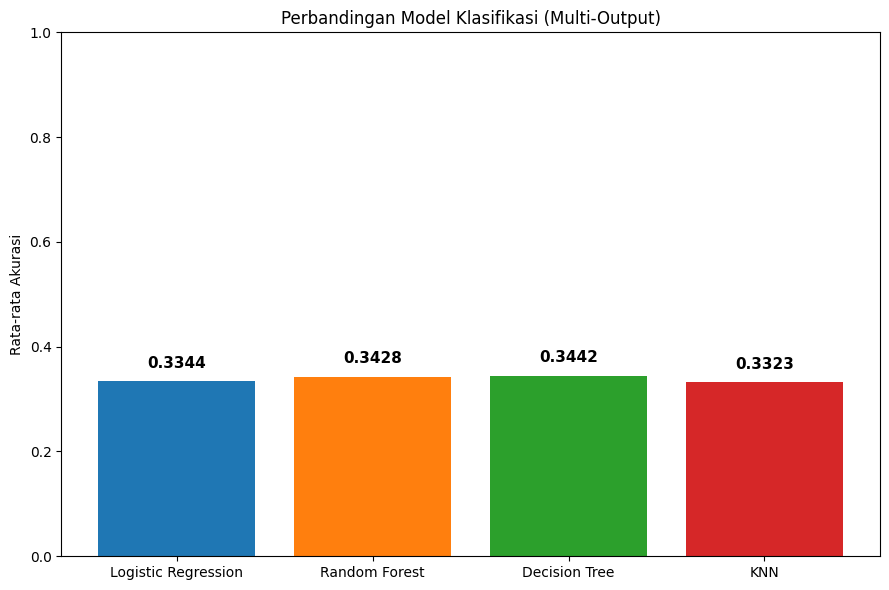

In [67]:
import matplotlib.pyplot as plt
import numpy as np


# Konversi y_test ke numpy array
y_true_np = y_test.values if hasattr(y_test, 'values') else np.array(y_test)

# MENGHITUNG RATA-RATA AKURASI (1 - Hamming Loss)
acc_lr = np.mean(y_true_np == y_pred_lr)
acc_rf = np.mean(y_true_np == y_pred_rf)
acc_dt = np.mean(y_true_np == y_pred_dt)
acc_knn = np.mean(y_true_np == y_pred_knn)

# Siapkan data untuk plot
model_names = ['Logistic Regression', 'Random Forest', 'Decision Tree', 'KNN']
accuracies = [acc_lr, acc_rf, acc_dt, acc_knn]


# Cari Model Terbaik
best_idx = np.argmax(accuracies)
best_model = model_names[best_idx]

print(f"🏆 Model Terbaik untuk arsitektur Multi-Output ini adalah: {best_model} 🏆\n")

# Membuat Bar Chart
plt.figure(figsize=(9, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
bars = plt.bar(model_names, accuracies, color=colors)

# Menambahkan nilai akurasi di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pengaturan Sumbu dan Judul
plt.ylim(0, 1.0)
plt.ylabel('Rata-rata Akurasi') # Label Y disesuaikan
plt.title('Perbandingan Model Klasifikasi (Multi-Output)')

plt.tight_layout()
plt.show()

Kesimpulan Perbandingan Model (Multi-Output Classification):

- Model Terbaik: Berdasarkan metrik rata-rata akurasi, Decision Tree keluar sebagai model dengan performa terbaik dengan skor 0.3442 (34.42%), unggul sangat tipis dibandingkan model lainnya.
- Performa Kompetitif: Random Forest menyusul di posisi kedua dengan skor yang sangat identik, yaitu 0.3428. Sementara itu, Logistic Regression (0.3344) dan KNN (0.3323) memberikan hasil yang paling rendah, meskipun perbedaannya tidak terlalu jauh.
- Analisis Skor: Secara keseluruhan, rata-rata akurasi untuk semua model berada di kisaran ~33-34%. Angka ini sekilas terlihat rendah, namun ini adalah hal yang wajar dan dapat dipahami dalam konteks klasifikasi Multi-Output, di mana model diwajibkan untuk menebak beberapa target sekaligus secara benar (Exact Match).

## Menyimpan Model 

In [68]:
import joblib

model_terbaik = model_dt

# 3. Simpan model ke file
joblib.dump(model_terbaik, 'model_multi_output.pkl')

print(f"✅ Model berhasil disimpan file: {model_terbaik}")

✅ Model berhasil disimpan file: DecisionTreeClassifier(random_state=42)


In [69]:
joblib.dump(sc, 'scaler.pkl')
joblib.dump(encoders, 'encoder.pkl')

['encoder.pkl']

In [70]:
list(x_train.columns)

['Age',
 'Years_of_Experience',
 'Hours_Worked_Per_Week',
 'Number_of_Virtual_Meetings',
 'Work_Life_Balance_Rating',
 'Social_Isolation_Rating',
 'Company_Support_for_Remote_Work',
 'Job_Role_Data Scientist',
 'Job_Role_Designer',
 'Job_Role_HR',
 'Job_Role_Marketing',
 'Job_Role_Project Manager',
 'Job_Role_Sales',
 'Job_Role_Software Engineer',
 'Access_to_Mental_Health_Resources_No',
 'Access_to_Mental_Health_Resources_Yes',
 'Productivity_Change_Decrease',
 'Productivity_Change_Increase',
 'Productivity_Change_No Change',
 'Satisfaction_with_Remote_Work_Neutral',
 'Satisfaction_with_Remote_Work_Satisfied',
 'Satisfaction_with_Remote_Work_Unsatisfied']